In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv('/content/car_age_price.csv')

In [3]:
data.head()

,Year,Price
0,2018,465000
1,2019,755000
2,2019,700000
3,2018,465000
4,2018,465000


In [4]:
data.shape

(112, 2)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    112 non-null    int64
 1   Price   112 non-null    int64
dtypes: int64(2)
memory usage: 1.9 KB


In [6]:
data.describe()

,Year,Price
count,112.000000,112.000000
mean,2016.669643,483866.044643
std,1.629616,91217.450533
min,2013.000000,300000.000000
25%,2015.000000,423750.000000
50%,2017.000000,500000.000000
75%,2017.000000,550000.000000
max,2020.000000,755000.000000


In [7]:
data.isnull().sum()

,0
Year,0
Price,0


In [8]:
data.duplicated().sum()

np.int64(54)

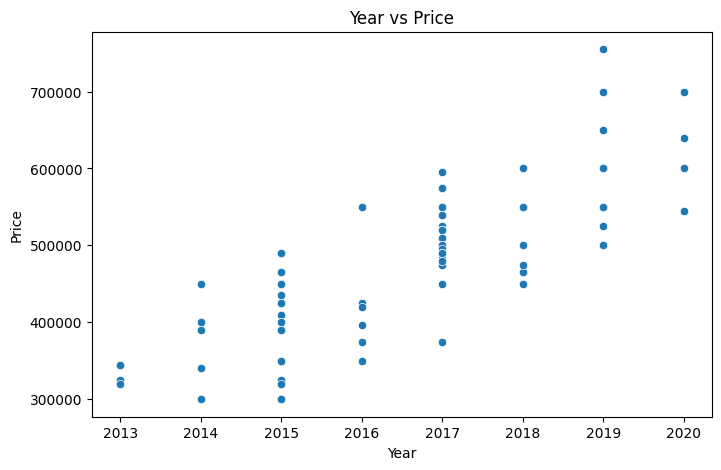

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='Year', y='Price')
plt.title("Year vs Price")
plt.show()

In [10]:
X = data[['Year']]
y = data['Price']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred_lr = lr.predict(X_test)

print(y_pred_lr)

[600775.91252081 505558.77690466 553167.34471273 553167.34471273
 553167.34471273 410341.6412885  505558.77690466 553167.34471273
 600775.91252081 600775.91252081 315124.50567235 505558.77690466
 410341.6412885  648384.48032889 553167.34471273 600775.91252081
 315124.50567235 410341.6412885  505558.77690466 505558.77690466
 505558.77690466 505558.77690466 505558.77690466]


In [14]:
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("MSE :", mean_squared_error(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score :", r2_score(y_test, y_pred_lr))

MAE : 53534.77957001264
MSE : 4326906256.829671
RMSE : 65779.22359552195
R2 Score : 0.36759313425902185


In [17]:
price_2022 = lr.predict([[2022]])

print("Predicted Price:", price_2022[0])

Predicted Price: 743601.6159450412


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
price_2022 = lr.predict(pd.DataFrame([[2022]], columns=['Year']))

In [19]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [20]:
y_pred_lasso = lasso.predict(X_test)

In [21]:
print("MAE :", mean_absolute_error(y_test, y_pred_lasso))
print("MSE :", mean_squared_error(y_test, y_pred_lasso))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score :", r2_score(y_test, y_pred_lasso))

MAE : 53534.73464390959
MSE : 4326901608.19506
RMSE : 65779.18826038415
R2 Score : 0.36759381368868127


In [22]:
price_2022_lasso = lasso.predict(pd.DataFrame([[2022]], columns=['Year']))

print("Predicted Price:", price_2022_lasso[0])

Predicted Price: 743601.3917776793


In [23]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Lasso Regression"],
    "R2 Score":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_lasso)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,y_pred_lr)),
        np.sqrt(mean_squared_error(y_test,y_pred_lasso))
    ]
})

comparison

,Model,R2 Score,RMSE
0,Linear Regression,0.367593,65779.223596
1,Lasso Regression,0.367594,65779.188260


In [24]:
if comparison.loc[0,"R2 Score"] > comparison.loc[1,"R2 Score"]:
    print("Linear Regression performs better.")
else:
    print("Lasso Regression performs better.")

Lasso Regression performs better.
